# Assignment
## Implement calibrator for Tree

* Background: In the Black--Scholes model volatility is a key parameter that determines option price. In a Balanced Binomial Tree (i.e. risk-neutral up step probability $= 0.5$ risk-neutral down step probability $= 0.5$) the same role is played by step size: higher step is like higher volatility, it results in higher option prices. Also, there is a 1-1 correspondence between step size and price if all other parameters are fixed.
* Task: Write a calibrate method which, for a given number of steps parameter, computes the up step size for which a Balanced Binomial Tree model returns the specified price for a given European call. (In practice option prices can be observed in the market, so it makes sense to assume it is given). Demonstrate the calibrate method for various input parameters (same contract with a few different number of steps (dont forget to scale the discount factor to keep interest rates flat); calibrate one step tree for various contracts (different expiries and strike levels, flat interest rate)). Make simple plots to illustrate results.
* Hint: To do it you will need to use a root solver, I recommend using scipy.optimize.minimize.

In [146]:
import numpy as np 
import matplotlib.pyplot as plt 
from typing import Dict, List, Union
from scipy.stats import norm
from scipy.optimize import minimize_scalar

In [147]:
def european_call_payoff(
        S: float, 
        K: float) -> float:
    return max(S-K, 0.0)


def create_spot_tree(
        spot: float, 
        spot_mult_up: float, 
        spot_mult_down: float,
        steps: int) -> list[list[float]]:
    
    previous_level = [spot]
    tree = [previous_level]
    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level
    return tree

def calcBalancedDownStep(spot_mult_up: float, discount_factor: float) -> float:
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)



In [148]:
def create_discounted_price_tree(
        spot_tree: list[list[float]], 
        discount_factor: float,
        K: float, 
        diag: int = 0) -> list[list[float]]:
    
    spot = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1] / spot 
    spot_mult_down = spot_tree[1][0] / spot

    p_up = ((1 / discount_factor - spot_mult_down) /
                   (spot_mult_up - spot_mult_down))
    p_down = 1 - p_up
    
    steps = len(spot_tree) - 1
    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]
    if diag > 0:
        print("risk-neutral measure: ")
        print(('%.3f' % p_up, '%.3f' % p_down))
        # init delta tree
        delta_tree = [[np.nan for _ in level] for level in spot_tree[:-1]] #delta makes no sense for leaves
    # going backwards, payoff is known in leaves


    for i in range(len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = discount_factor**(steps) * european_call_payoff(spot, K)
        continuation_value_tree[-1][i] = discounted_continuation_value
        continuation_value_tree[-1][i] = discounted_continuation_value

        
    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            continuation_value_tree[step][i] = p_up * continuation_value_tree[step + 1][i] + \
                                            p_down * continuation_value_tree[step + 1][i + 1]
            if diag > 0:
                delta_tree[step][i] = ((continuation_value_tree[step + 1][i] - continuation_value_tree[step + 1][i + 1]) 
                                       / (spot_tree[step + 1][i] - spot_tree[step + 1][i + 1]))
    if diag > 0:
        print("delta: ")
        delta_tree_readable = [['%.3f' % e for e in n] for n in delta_tree]
        print(delta_tree_readable)
    return continuation_value_tree

In [149]:
spot = 100
spot_mult_up = 1.2
spot_mult_down = 0.8
steps = 5
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)

spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]

discount_factor = 0.95
strike = 80
diag = 1

price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, diag)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("Price tree:")
price_tree_readable

risk-neutral measure: 
('0.632', '0.368')
delta: 
[['0.357'], ['0.257', '0.514'], ['0.126', '0.438', '0.661'], ['-0.000', '0.284', '0.667', '0.733'], ['-0.000', '-0.000', '0.642', '0.774', '0.774']]
Price tree:


[['9.475'],
 ['4.215', '18.493'],
 ['1.184', '9.411', '34.061'],
 ['0.000', '3.213', '20.037', '58.103'],
 ['0.000', '0.000', '8.721', '39.435', '90.104'],
 ['0.000', '0.000', '0.000', '23.672', '66.458', '130.639']]

We need a function to calculate the exact option price 

In [150]:
"""The pricing function of European call option BS model"""
def black_scholes_eur_call(
        r: float, 
        T: float, 
        S0: float, 
        sigma: float, 
        K: Union[float, List[float]]) -> Dict:

    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1 = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2 = d1 - sigma * T**0.5

    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    price = N_d1 * S0 - K * np.exp(-r * T) * N_d2
    return price
    
"""The pricing function of European call option tree model"""
def tree_price(
        up : float,
        disc: float, 
        S0: float,
        K: float, 
        step: int )-> float:
    
    # Calculating option price approximation
    down = calcBalancedDownStep(up, disc)
    spot_tree = create_spot_tree(S0, up, down, step)
    price_tree = create_discounted_price_tree(spot_tree, disc, K)
    return  price_tree[0][0]


In [151]:
def calibrate_up_step(
        r : float, 
        T : float, 
        S0 : float, 
        K : float,
        sigma: float,
        step: int) -> float:
    """
    Calibrate the up-step size (spot_mult_up) for a Balanced Binomial Tree
    so that the tree price matches the Black-Scholes price.
    """
    #adjusting discount factor 
    discount_factor = np.exp(-r * (T / step))
    market_price = black_scholes_eur_call(r, T, S0, sigma, K)

    # error function for optimization
    def objective(spot_mult_up):

        tree_price_res = tree_price(spot_mult_up, discount_factor, S0, K, step)

        # Return the absolute difference between tree price and market price, it can be squared error as well 
        return abs(tree_price_res - market_price)
    
    # Optimize spot_mult_up
    result = minimize_scalar(objective, bounds=(1.0, 5.0), method='bounded')
    if result.success:
        return result.x
    else:
        raise ValueError("Calibration failed")


In [152]:
r = 0.05  
T = 1.0   
S0 = 100 
K = 80   
sigma = 0.25  
N = 10  # Number of tree steps

calibrated_up_step = calibrate_up_step(r, T, S0, K, sigma, N)
market_price = black_scholes_eur_call(r, T, S0, sigma, K)
tree_price_res = tree_price(calibrated_up_step, np.exp(-r*(T/N)), S0, K, N)
print(market_price)
print(tree_price_res)
print(f"Calibrated up-step size: {calibrated_up_step:.4f}")


25.412511998314315
25.412435534322782
Calibrated up-step size: 1.0828


How does calibrated u depends on stepsize?

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


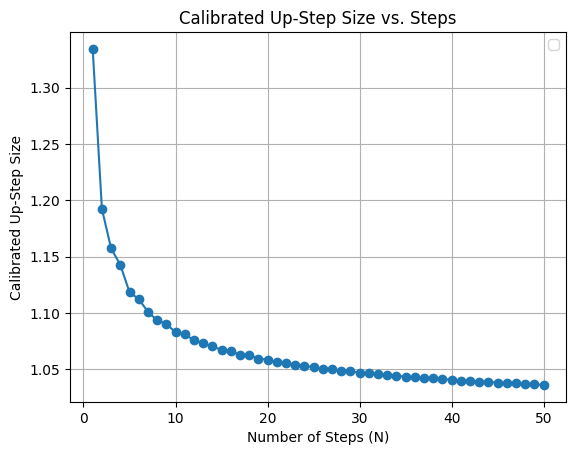

In [153]:
steps = np.linspace(1,50,50)
up_steps = []
for step in steps: 
    calibrated_up_step = calibrate_up_step(r, T, S0, K, sigma, int(step))
    up_steps.append(calibrated_up_step)

plt.plot(steps, up_steps, marker='o')
plt.xlabel("Number of Steps (N)")
plt.ylabel("Calibrated Up-Step Size")
plt.title("Calibrated Up-Step Size vs. Steps")
plt.legend()
plt.grid()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9436\849299953.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  up_step_surface[i, j] = calibrate_up_step(r, T_mesh[i, j], S0, K_mesh[i, j], sigma, 10)


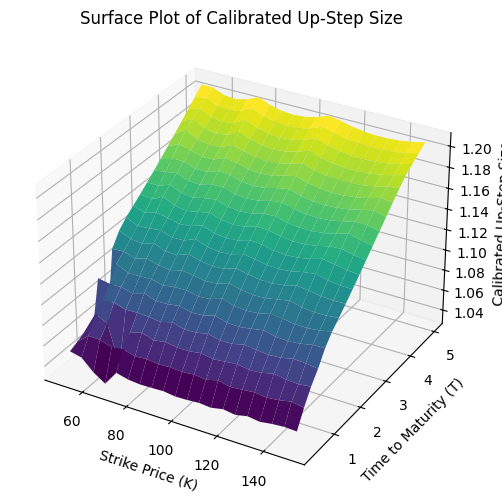

In [154]:
K_vals = np.linspace(50, 150, 20)
T_vals = np.linspace(0.25, 5, 20)
K_mesh, T_mesh = np.meshgrid(K_vals, T_vals)
up_step_surface = np.zeros_like(K_mesh)

for i in range(K_mesh.shape[0]):
    for j in range(K_mesh.shape[1]):
        up_step_surface[i, j] = calibrate_up_step(r, T_mesh[i, j], S0, K_mesh[i, j], sigma, 10)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_mesh, T_mesh, up_step_surface, cmap='viridis')
ax.set_xlabel("Strike Price (K)")
ax.set_ylabel("Time to Maturity (T)")
ax.set_zlabel("Calibrated Up-Step Size")
ax.set_title("Surface Plot of Calibrated Up-Step Size")
plt.show()


Flat interest rate

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


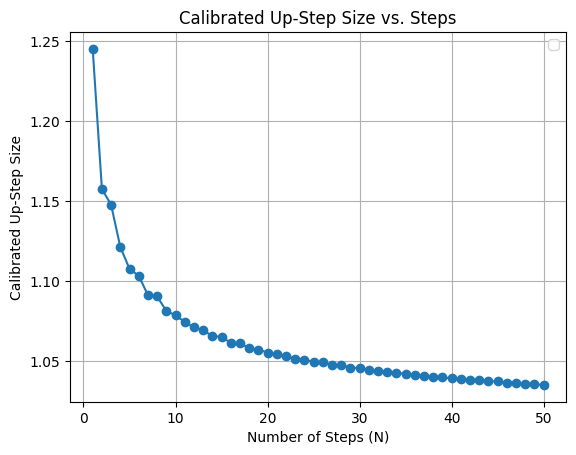

In [155]:
steps = np.linspace(1,50,50)
up_steps = []
for step in steps: 
    calibrated_up_step = calibrate_up_step(0, T, S0, K, sigma, int(step))
    up_steps.append(calibrated_up_step)

plt.plot(steps, up_steps, marker='o')
plt.xlabel("Number of Steps (N)")
plt.ylabel("Calibrated Up-Step Size")
plt.title("Calibrated Up-Step Size vs. Steps")
plt.legend()
plt.grid()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9436\4283874565.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  up_step_surface[i, j] = calibrate_up_step(0, T_mesh[i, j], S0, K_mesh[i, j], sigma, 10)


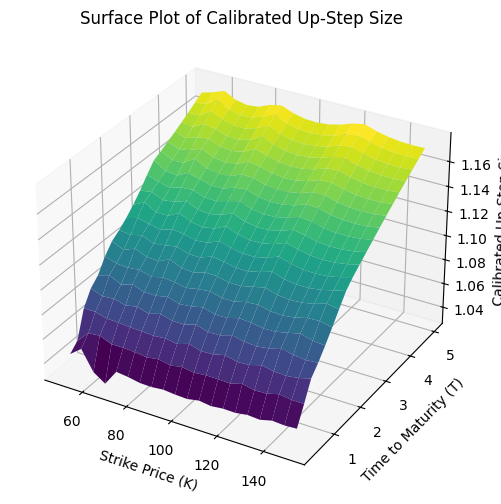

In [156]:
K_vals = np.linspace(50, 150, 20)
T_vals = np.linspace(0.25, 5, 20)
K_mesh, T_mesh = np.meshgrid(K_vals, T_vals)
up_step_surface = np.zeros_like(K_mesh)

for i in range(K_mesh.shape[0]):
    for j in range(K_mesh.shape[1]):
        up_step_surface[i, j] = calibrate_up_step(0, T_mesh[i, j], S0, K_mesh[i, j], sigma, 10)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_mesh, T_mesh, up_step_surface, cmap='viridis')
ax.set_xlabel("Strike Price (K)")
ax.set_ylabel("Time to Maturity (T)")
ax.set_zlabel("Calibrated Up-Step Size")
ax.set_title("Surface Plot of Calibrated Up-Step Size")
plt.show()
